In [ ]:
!pip install librosa -q

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

from tqdm import tqdm

In [ ]:
import zipfile
import os

zip_file = "/content/CREMA-D.zip"

extract_path = "/content/cremad_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
emotion_map = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

In [ ]:
data = []

wav_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(os.path.join(root, file))

print("Total files:", len(wav_files))

Total files: 7442


In [ ]:
for file_path in tqdm(wav_files):

    try:
        signal, sr = librosa.load(file_path, sr=None)

        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)

        zcr = np.mean(librosa.feature.zero_crossing_rate(signal))

        rms = np.mean(librosa.feature.rms(y=signal))

        filename = os.path.basename(file_path)

        emotion_code = filename.split("_")[2]

        emotion = emotion_map.get(emotion_code)

        row = list(mfcc_mean)
        row.extend([zcr, rms, emotion])

        data.append(row)

    except:
        pass

100%|██████████| 7442/7442 [02:23<00:00, 51.81it/s]


In [ ]:
columns = [f"MFCC_{i}" for i in range(1,14)]
columns += ["ZCR", "RMS", "Emotion"]

df = pd.DataFrame(data, columns=columns)

df.head()

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,ZCR,RMS,Emotion
0,-359.721893,106.060867,26.629133,35.714722,3.187202,-3.982386,-1.665128,-6.085124,4.070709,-2.608798,2.320486,3.825969,-2.513191,0.067131,0.021953,Happy
1,-381.368011,106.444260,40.499851,25.877035,6.061241,0.979075,9.007453,-1.645031,-3.468782,-1.138598,-1.820686,2.919791,-2.315080,0.059636,0.014484,Disgust
2,-363.800781,114.034798,34.466515,22.248247,6.891284,1.083175,-1.614798,-6.456960,-1.690817,-1.729440,1.093558,1.504226,-3.601207,0.062789,0.014133,Fear
3,-316.146942,90.169998,23.203302,24.176964,8.712356,-4.670783,-7.196138,0.766733,-1.500140,-1.240322,-7.106519,-2.124092,-5.967351,0.091379,0.039913,Fear
4,-309.199005,68.311607,30.528130,27.450670,14.803609,-5.320282,-0.750477,-2.905038,0.492008,-0.115277,-3.364537,1.271234,-8.666280,0.164090,0.038087,Happy


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop("Emotion", axis=1)

y = df["Emotion"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm.fit(X_train, y_train)

SVC(C=10)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average='weighted'
)

svm_mse = mean_squared_error(
    y_test,
    svm_pred
)

print("SVM Accuracy:", svm_acc)
print("SVM F1:", svm_f1)
print("SVM MSE:", svm_mse)

print(classification_report(
    y_test,
    svm_pred,
    target_names=encoder.classes_
))

SVM Accuracy: 0.47750167897918067
SVM F1: 0.4760366478531238
SVM MSE: 3.0322364002686366
              precision    recall  f1-score   support

       Angry       0.61      0.62      0.61       254
     Disgust       0.42      0.43      0.42       254
        Fear       0.40      0.37      0.38       254
       Happy       0.44      0.41      0.42       255
     Neutral       0.46      0.47      0.47       218
         Sad       0.53      0.56      0.54       254

    accuracy                           0.48      1489
   macro avg       0.47      0.48      0.48      1489
weighted avg       0.48      0.48      0.48      1489



In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error

mlp_pred = mlp.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)

mlp_f1 = f1_score(
    y_test,
    mlp_pred,
    average='weighted'
)

mlp_mse = mean_squared_error(
    y_test,
    mlp_pred
)

print("MLP Accuracy:", mlp_acc)
print("MLP F1:", mlp_f1)
print("MLP MSE:", mlp_mse)

print(classification_report(
    y_test,
    mlp_pred,
    target_names=encoder.classes_
))

MLP Accuracy: 0.4170584284754869
MLP F1: 0.41649591441512923
MLP MSE: 3.433176628609805
              precision    recall  f1-score   support

       Angry       0.59      0.62      0.60       254
     Disgust       0.31      0.32      0.32       254
        Fear       0.34      0.33      0.33       254
       Happy       0.39      0.38      0.38       255
     Neutral       0.38      0.41      0.40       218
         Sad       0.48      0.44      0.46       254

    accuracy                           0.42      1489
   macro avg       0.42      0.42      0.42      1489
weighted avg       0.42      0.42      0.42      1489



In [ ]:
comparison = pd.DataFrame({
    "Model": ["SVM", "MLP (2 Hidden Layers)"],
    "Accuracy": [svm_acc, mlp_acc],
    "Weighted F1": [svm_f1, mlp_f1]
})

comparison

,Model,Accuracy,Weighted F1
0,SVM,0.477502,0.476037
1,MLP (2 Hidden Layers),0.417058,0.416496


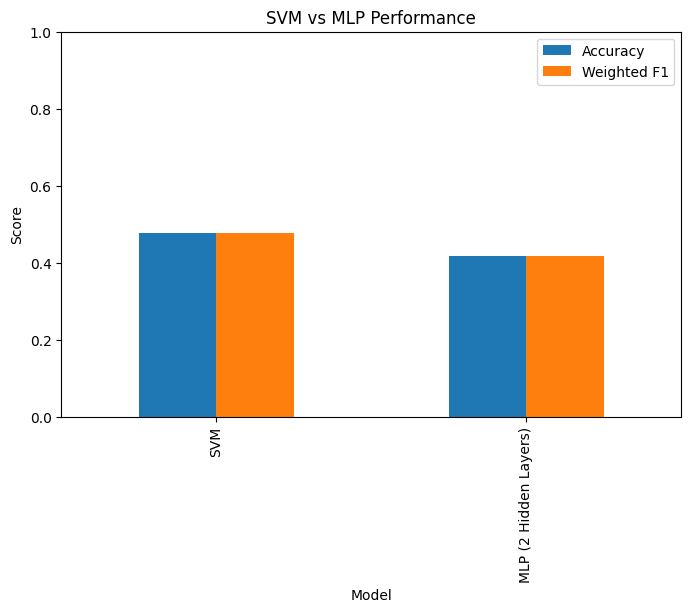

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("SVM vs MLP Performance")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

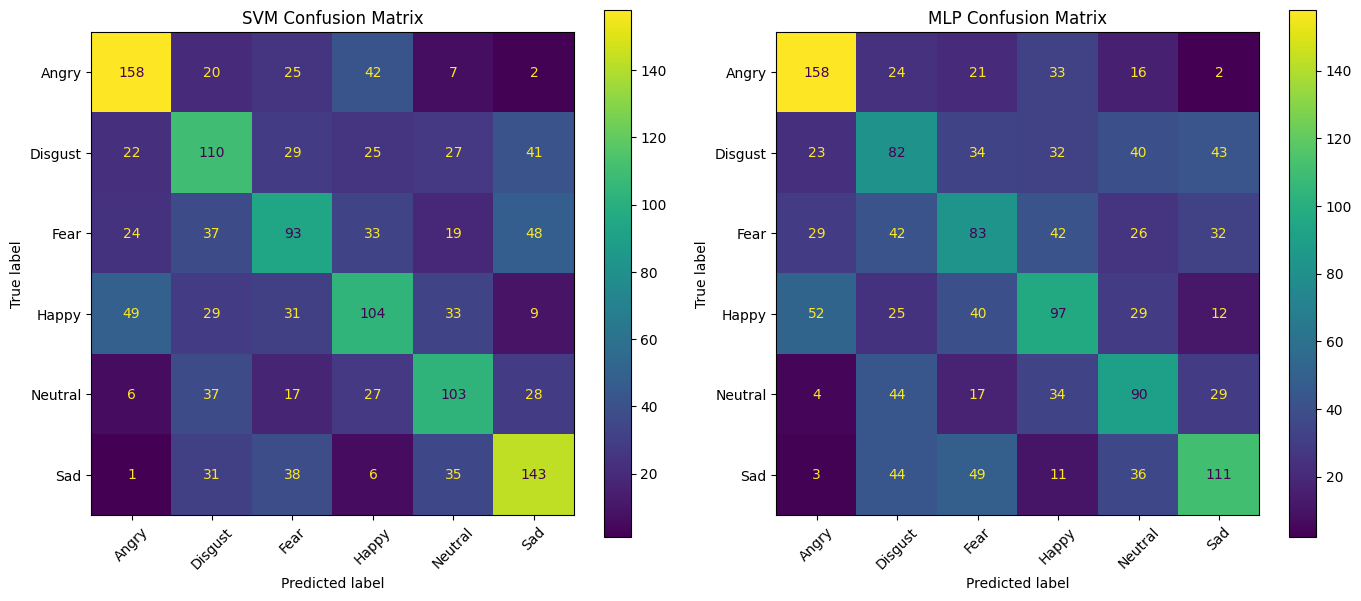

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# SVM
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=encoder.classes_,
    ax=ax[0],
    xticks_rotation=45
)
ax[0].set_title("SVM Confusion Matrix")

# MLP
ConfusionMatrixDisplay.from_predictions(
    y_test,
    mlp_pred,
    display_labels=encoder.classes_,
    ax=ax[1],
    xticks_rotation=45
)
ax[1].set_title("MLP Confusion Matrix")

plt.tight_layout()
plt.show()